# Healthcare Insurance Claims Analysis – Data Analytics Final Project

## Data Analytics Final Project

### Submitted By:
### Anchu D

# Problem Definition & Dataset Selection

## Problem Statement

The healthcare industry generates a massive amount of patient and insurance claim data every day.

Analyzing this data helps healthcare organizations identify trends in claim approvals, rejections, revenue generation, department performance, insurance provider contributions, and operational efficiency.

The analysis includes data cleaning, exploratory data analysis (EDA), visualization, and business insights generation using Python libraries.

## Objective

The objective of this project is to perform a complete Exploratory Data Analysis (EDA) on a healthcare claims dataset to:

- Understand claim submission and approval patterns
- Analyze revenue generated from different departments and doctors
- Identify insurance providers with the highest claim amounts
- Examine rejected and outstanding claims
- Generate actionable business insights using data visualization and statistical analysis

## Dataset Overview

The dataset contains healthcare insurance claim records with information about:

- Patient visits
- Doctors and departments
- Insurance companies and plans
- Claim submission amounts
- Approval/rejection status
- Outstanding and received amounts
- Medical item categories

## Dataset Size

- Rows: 72,804
- Columns: 19

## Tools & Libraries Used

Tools & Technologies Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


# Data Loading and Initial Overview




In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [15]:
!pip install openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
df = pd.read_excel("Healthcare_Dataset.xlsx")

## View First 5 Rows


In [18]:
df.head()

,SlNo,VisitNo,VisitDate,UniqueID,EncPatID,DepName,DocName,Insurance,InsGroup,InsPlan,ActivityStatus,Code,Submission Amount,DenialCode,Received Amount,Rejected Amount,Outstanding,Accepted Amount,Item Group
0,1,189069,2024-12-01,1733280758243,74488,GENERAL PRACTICE DEPARTMENT,SHARIFUL ISLAM,NATIONAL HEALTH INSURANCE COMPANY (DAMAN),NETWORK 3,ABU DHABI PLAN,Approved,99212,36.00,NaN,36.00,NaN,NaN,NaN,Consultation
1,2,189070,2024-12-01,1733280758376,25644,GENERAL PRACTICE DEPARTMENT,SHARIFUL ISLAM,NATIONAL HEALTH INSURANCE COMPANY (DAMAN),NETWORK 3,ABU DHABI PLAN,Approved,94640,32.00,NaN,32.00,NaN,NaN,NaN,Procedure
2,3,189070,2024-12-01,1733280758376,25644,GENERAL PRACTICE DEPARTMENT,SHARIFUL ISLAM,NATIONAL HEALTH INSURANCE COMPANY (DAMAN),NETWORK 3,ABU DHABI PLAN,Approved,96374,20.00,NaN,20.00,NaN,NaN,NaN,Procedure
3,4,189070,2024-12-01,1733280758376,25644,GENERAL PRACTICE DEPARTMENT,SHARIFUL ISLAM,NATIONAL HEALTH INSURANCE COMPANY (DAMAN),NETWORK 3,ABU DHABI PLAN,Approved,C96-4083-04308-01,9.66,NaN,9.66,NaN,NaN,NaN,Medicines
4,5,189070,2024-12-01,1733280758376,25644,GENERAL PRACTICE DEPARTMENT,SHARIFUL ISLAM,NATIONAL HEALTH INSURANCE COMPANY (DAMAN),NETWORK 3,ABU DHABI PLAN,Approved,99212,36.00,NaN,36.00,NaN,NaN,NaN,Consultation


## Dataset Shape Analysis



In [20]:
df.shape

(72804, 19)

This means the dataset contains:

- 72,804 records
- 19 columns

## Display Column Names

In [22]:
df.columns

Index([' SlNo ', ' VisitNo ', 'VisitDate', 'UniqueID', ' EncPatID ',
       ' DepName ', ' DocName ', ' Insurance ', ' InsGroup ', ' InsPlan ',
       ' ActivityStatus ', ' Code ', 'Submission Amount', ' DenialCode ',
       'Received Amount', 'Rejected Amount', 'Outstanding', 'Accepted Amount',
       ' Item Group '],
      dtype='str')

## Dataset Information

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72804 entries, 0 to 72803
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0    SlNo              72804 non-null  int64         
 1    VisitNo           72804 non-null  int64         
 2   VisitDate          72804 non-null  datetime64[us]
 3   UniqueID           72804 non-null  int64         
 4    EncPatID          72804 non-null  int64         
 5    DepName           72804 non-null  str           
 6    DocName           72804 non-null  str           
 7    Insurance         72804 non-null  str           
 8    InsGroup          72804 non-null  str           
 9    InsPlan           72804 non-null  str           
 10   ActivityStatus    72804 non-null  str           
 11   Code              72804 non-null  str           
 12  Submission Amount  72804 non-null  float64       
 13   DenialCode        7888 non-null   str           
 14  Received Amount  

Key Observations
- Dataset contains numerical, categorical, and datetime columns.
- Some columns contain missing values.
- VisitDate is already in datetime format.
- Financial columns are in float format.

## Statistical Summary

In [26]:
df.describe()

,SlNo,VisitNo,VisitDate,UniqueID,EncPatID,Submission Amount,Received Amount,Rejected Amount,Outstanding,Accepted Amount
count,72804.000000,72804.000000,72804,7.280400e+04,72804.000000,72804.000000,72804.000000,5534.000000,13364.000000,1728.000000
mean,36527.267142,205242.793006,2025-02-11 11:19:18.859403,1.740834e+12,62794.229562,25.033383,17.106215,41.886357,24.528391,10.146415
min,1.000000,189069.000000,2024-12-01 00:00:00,1.733281e+12,51.000000,0.000000,-2.500000,0.000000,0.000000,0.000000
25%,18242.750000,197292.750000,2025-01-01 00:00:00,1.737084e+12,48028.000000,0.000000,0.000000,20.000000,0.000000,0.010000
50%,36522.500000,204934.500000,2025-02-01 00:00:00,1.740453e+12,70230.000000,20.000000,0.000000,44.800000,20.000000,3.200000
75%,54796.250000,213026.000000,2025-04-01 00:00:00,1.744687e+12,80466.500000,36.000000,36.000000,62.720000,36.000000,9.660000
max,73131.000000,221880.000000,2025-05-01 00:00:00,1.749180e+12,87060.000000,620.000000,620.000000,620.000000,620.000000,348.000000
std,21107.815605,9219.812555,NaN,4.420644e+09,21249.343134,28.794865,26.141715,29.264211,28.022303,22.442808


This provides:

- Mean
- Standard deviation
- Minimum and maximum values
- Quartile distribution

# Data Pre-processing

### Remove Extra Spaces from Column Names

In [29]:
df.columns = df.columns.str.strip()

### Check Missing Values

In [31]:
df.isnull().sum()

SlNo                     0
VisitNo                  0
VisitDate                0
UniqueID                 0
EncPatID                 0
DepName                  0
DocName                  0
Insurance                0
InsGroup                 0
InsPlan                  0
ActivityStatus           0
Code                     0
Submission Amount        0
DenialCode           64916
Received Amount          0
Rejected Amount      67270
Outstanding          59440
Accepted Amount      71076
Item Group               0
dtype: int64

Major Missing Values
- Column	                  Missing Values
- Accepted Amount	            71,076
- Rejected Amount	            67,270
- DenialCode	                64,916
- Outstanding	                59,440

In [32]:
# Replace missing numerical values with 0
num_cols = ['Rejected Amount', 'Outstanding', 'Accepted Amount']

for col in num_cols:
    df[col] = df[col].fillna(0)

In [33]:
# Replace missing denial codes
# If no denial code exists, mark as 'No Denial'
df['DenialCode'] = df['DenialCode'].fillna('No Denial')

## Check Duplicate Records

In [35]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found.

# Create Derived Columns

## Extract Month and Day

In [39]:
df['Month'] = df['VisitDate'].dt.month_name()
df['Day'] = df['VisitDate'].dt.day_name()

# Exploratory Data Analysis (EDA)

# 1. Department-wise Analysis

### Total Submission Amount by Department

In [41]:
dept_analysis = df.groupby('DepName')['Submission Amount'].sum().sort_values(ascending=False)

print(dept_analysis)

DepName
GENERAL PRACTICE DEPARTMENT    1736931.41
PHYSIOTHERAPY                    83887.00
DENTAL DEPARTMENT                 1712.00
Name: Submission Amount, dtype: float64


## Visualization

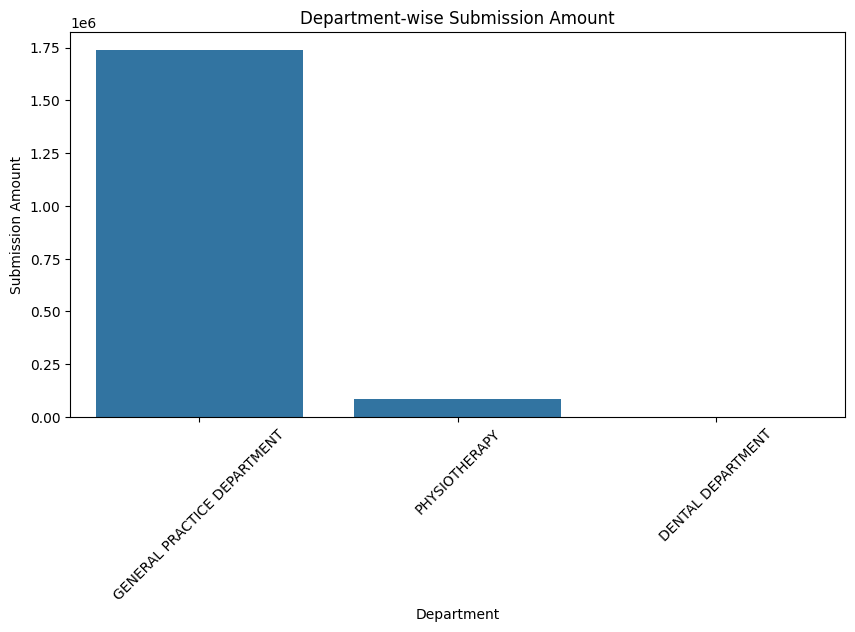

In [111]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=dept_analysis.index,
    y=dept_analysis.values
)

plt.title('Department-wise Submission Amount')
plt.xlabel('Department')
plt.ylabel('Submission Amount')
plt.xticks(rotation=45)
plt.show()

General Practice Department contributes more than 90% of total claims.

# 2. Doctor-wise Analysis

## Top Doctors by Submission Amount

In [44]:
doctor_analysis = df.groupby('DocName')['Submission Amount'].sum().sort_values(ascending=False)

doctor_analysis.head(10)

DocName
RAGHA MOHAN KOTHUR               313791.271
SHARIFUL ISLAM                   296169.625
SHER BAZ  KHAN                   295420.090
SHAKIR ULLAH KHAN                293674.090
GAJENDRA VASHISTH                289780.026
NURUL ISLAM                      142620.418
MOHAMED RASEEN MOHAMED IDREES     81377.000
Habib  Khan                       78831.090
ASHFAQ UR REHMAN                  26644.800
SENTHILNATHAN    SELVAKUMAR        2510.000
Name: Submission Amount, dtype: float64

## Visualization

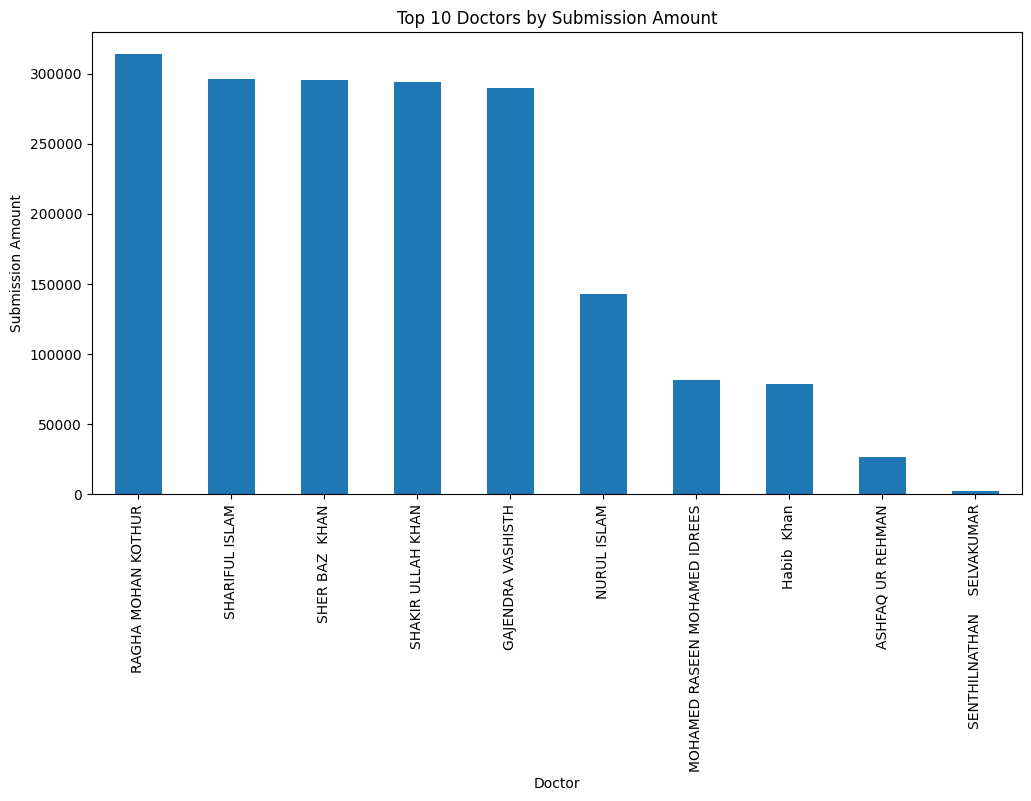

In [112]:
plt.figure(figsize=(12,6))

doctor_analysis.head(10).plot(kind='bar')

plt.title('Top 10 Doctors by Submission Amount')
plt.ylabel('Submission Amount')
plt.xlabel('Doctor')
plt.show()

Dr. Ragha Mohan generated the highest revenue.

# 3. Insurance-wise Analysis

## Insurance Contribution

In [47]:
insurance_analysis = (
    df.groupby('Insurance')['Submission Amount']
      .sum()
      .sort_values(ascending=False)
)

insurance_analysis.head(10)

Insurance
NATIONAL HEALTH INSURANCE COMPANY (DAMAN)    865590.885
OMAN INSURANCE COMPANY                       338705.620
NAS ADMINISTRATION SERVICES LIMITED          160846.425
ALMADALLAH                                   154420.640
AAFIYA                                       103260.920
FMC NETWORK UAE MANAGEMENT CONSULTANCY       102299.480
MEDNET GLOBAL HEALTHCARE SOLUTIONS LLC        58842.050
E CARE MEDICAL SERVICES                       14057.260
INAYAH TPA LLC - ABU DHABI                    13218.450
ARAB GULF HEALTH SERVICES (NEXTCARE)           7517.830
Name: Submission Amount, dtype: float64

## Visualization

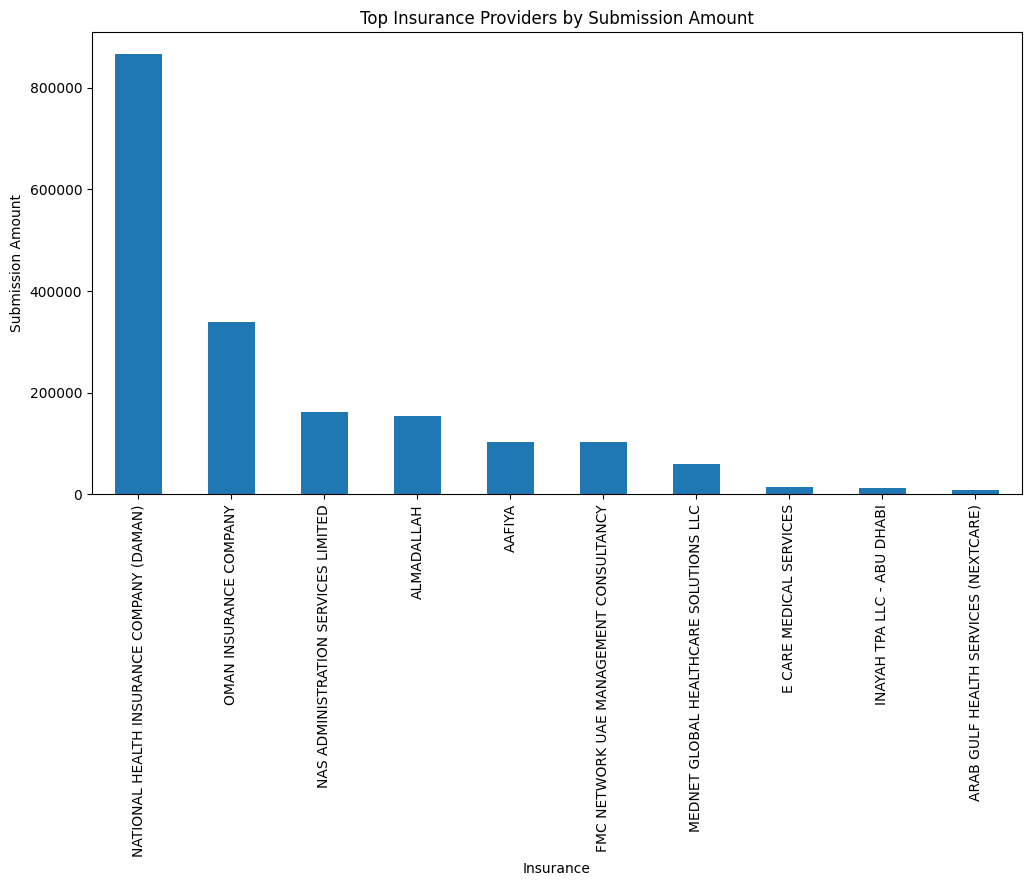

In [114]:
plt.figure(figsize=(12,6))

insurance_analysis.head(10).plot(
    kind='bar'
)

plt.title('Top Insurance Providers by Submission Amount')
plt.ylabel('Submission Amount')
plt.xlabel('Insurance')
plt.show()

Daman contributes the largest share of healthcare claims.

# 4. Insurance Rejection Analysis

In [121]:
rejection_analysis = (
    df.groupby('Insurance')['Rejected Amount']
      .sum()
      .sort_values(ascending=False)
)

rejection_analysis.head(10)

Insurance
OMAN INSURANCE COMPANY                               181348.980
NAS ADMINISTRATION SERVICES LIMITED                   25463.481
NATIONAL HEALTH INSURANCE COMPANY (DAMAN)             13845.510
ALMADALLAH                                             5550.880
ARAB GULF HEALTH SERVICES (NEXTCARE)                   3024.270
FMC NETWORK UAE MANAGEMENT CONSULTANCY                 1703.190
AAFIYA                                                  488.000
E CARE MEDICAL SERVICES                                 269.800
NATIONAL HEALTH INSURANCE COMPANY (DAMAN) - THIQA        56.000
NEURON LLC - ABU DHABI                                   22.990
Name: Rejected Amount, dtype: float64

## Visualization

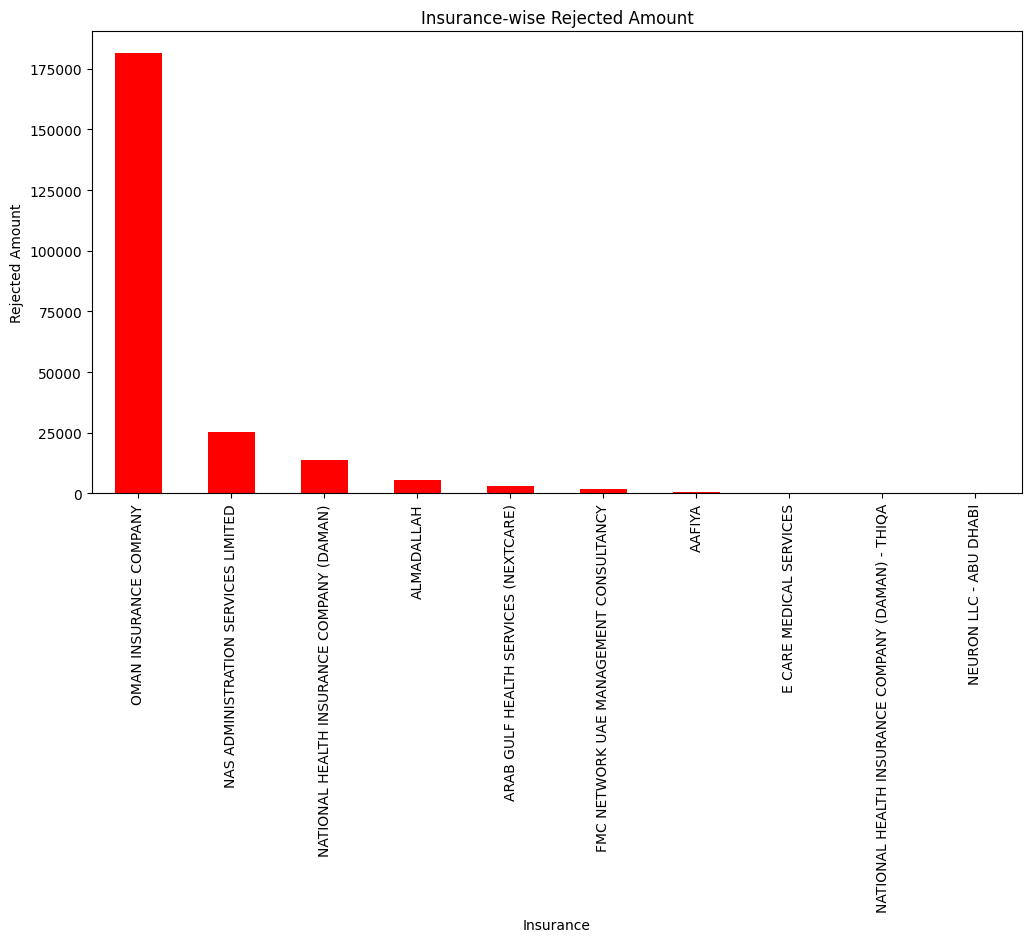

In [116]:
plt.figure(figsize=(12,6))

rejection_analysis.head(10).plot(
    kind='bar',
    color='red'
)

plt.title('Insurance-wise Rejected Amount')
plt.ylabel('Rejected Amount')
plt.xlabel('Insurance')
plt.show()

Oman Insurance has significantly higher rejection amounts compared to other insurers.

# 5. Item Group Analysis

In [52]:
item_analysis = (
    df.groupby('Item Group')['Submission Amount']
      .sum()
      .sort_values(ascending=False)
)

item_analysis

Item Group
Consultation    1338881.820
Procedure        394453.951
Medicines         46529.539
Lab               42665.100
Name: Submission Amount, dtype: float64

## Visualization

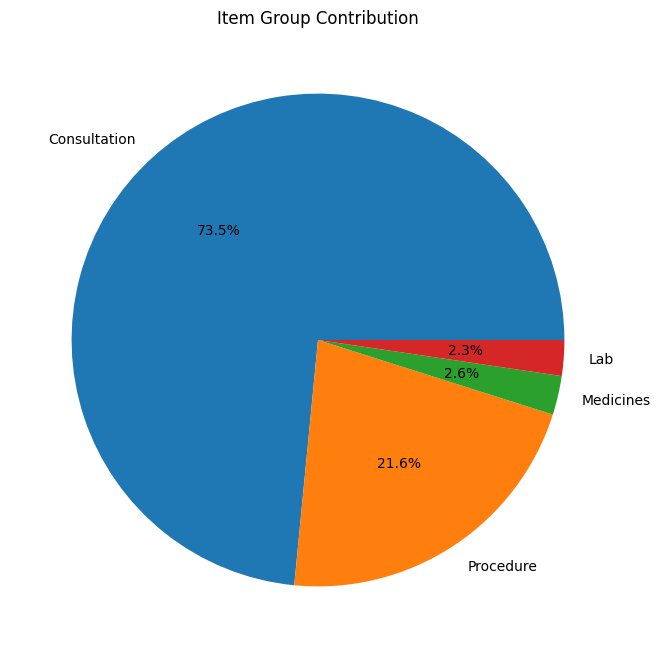

In [117]:
plt.figure(figsize=(8,8))

plt.pie(
    item_analysis.values,
    labels=item_analysis.index,
    autopct='%1.1f%%'
)

plt.title('Item Group Contribution')
plt.show()

Consultation services contribute the majority of healthcare revenue.

# Correlation Analysis

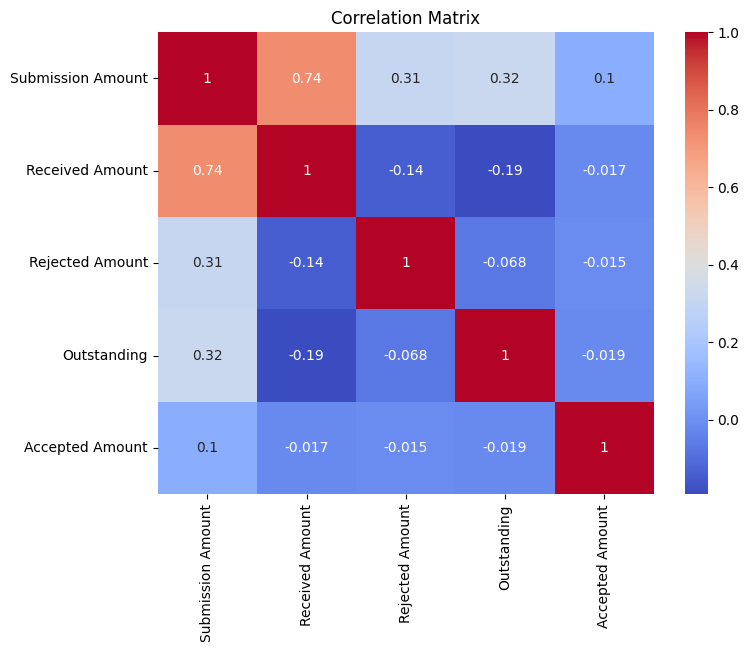

In [57]:
numeric_cols = [
    'Submission Amount',
    'Received Amount',
    'Rejected Amount',
    'Outstanding',
    'Accepted Amount'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

## Monthly Submission Amount Trend

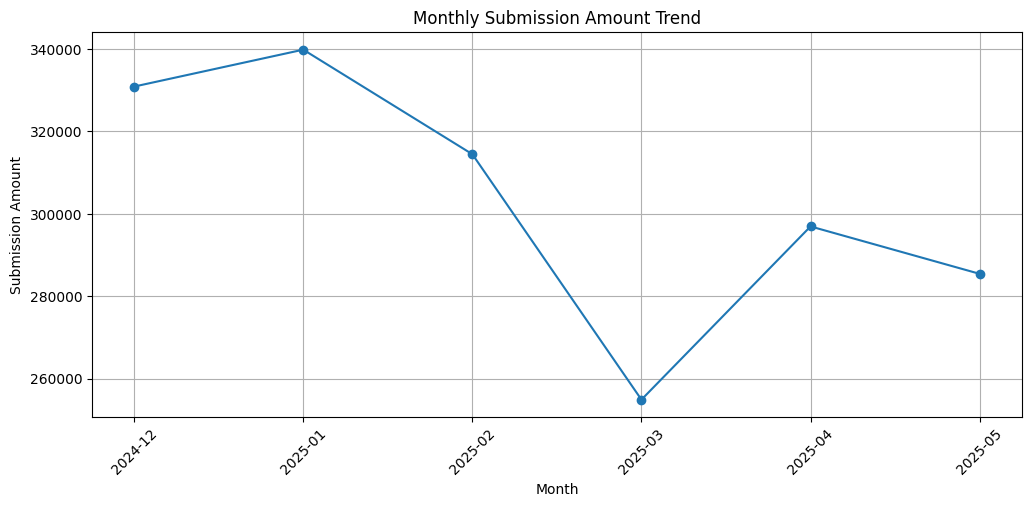

In [123]:
monthly_submission = df.groupby(
    df['VisitDate'].dt.to_period('M')
)['Submission Amount'].sum()

monthly_submission.index = monthly_submission.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_submission.index,
    monthly_submission.values,
    marker='o'
)

plt.title('Monthly Submission Amount Trend')
plt.xlabel('Month')
plt.ylabel('Submission Amount')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Statistical Summary

## Overall Dataset Summary

In [61]:
df.describe()

,SlNo,VisitNo,VisitDate,UniqueID,EncPatID,Submission Amount,Received Amount,Rejected Amount,Outstanding,Accepted Amount
count,72804.000000,72804.000000,72804,7.280400e+04,72804.000000,72804.000000,72804.000000,72804.000000,72804.000000,72804.000000
mean,36527.267142,205242.793006,2025-02-11 11:19:18.859403,1.740834e+12,62794.229562,25.033383,17.106215,3.183879,4.502464,0.240825
min,1.000000,189069.000000,2024-12-01 00:00:00,1.733281e+12,51.000000,0.000000,-2.500000,0.000000,0.000000,0.000000
25%,18242.750000,197292.750000,2025-01-01 00:00:00,1.737084e+12,48028.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,36522.500000,204934.500000,2025-02-01 00:00:00,1.740453e+12,70230.000000,20.000000,0.000000,0.000000,0.000000,0.000000
75%,54796.250000,213026.000000,2025-04-01 00:00:00,1.744687e+12,80466.500000,36.000000,36.000000,0.000000,0.000000,0.000000
max,73131.000000,221880.000000,2025-05-01 00:00:00,1.749180e+12,87060.000000,620.000000,620.000000,620.000000,620.000000,348.000000
std,21107.815605,9219.812555,NaN,4.420644e+09,21249.343134,28.794865,26.141715,13.722657,15.306858,3.785975


## Summary of Financial Columns

In [63]:
financial_cols = [
    'Submission Amount',
    'Accepted Amount',
    'Rejected Amount',
    'Received Amount',
    'Outstanding'
]

df[financial_cols].describe()

,Submission Amount,Accepted Amount,Rejected Amount,Received Amount,Outstanding
count,72804.000000,72804.000000,72804.000000,72804.000000,72804.000000
mean,25.033383,0.240825,3.183879,17.106215,4.502464
std,28.794865,3.785975,13.722657,26.141715,15.306858
min,0.000000,0.000000,0.000000,-2.500000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,0.000000,0.000000,0.000000,0.000000
75%,36.000000,0.000000,0.000000,36.000000,0.000000
max,620.000000,348.000000,620.000000,620.000000,620.000000


- Mean submission amount represents average claim value.
- Maximum values indicate high-value claims.
- Standard deviation shows variation in claim amounts.

# Univariate Analysis

## Distribution of Submission Amount

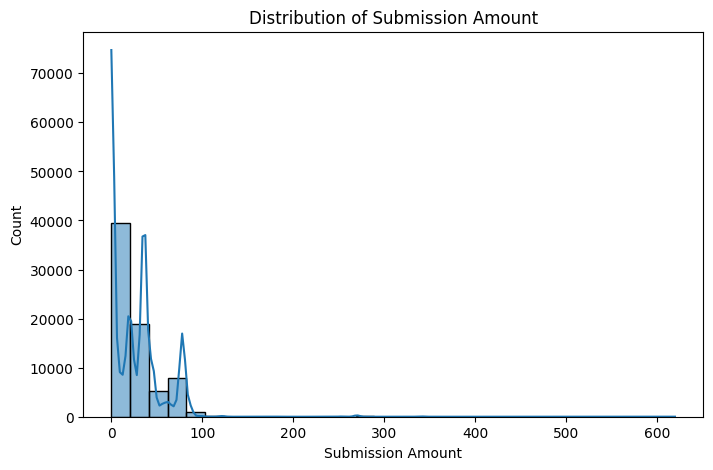

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Submission Amount'],
    bins=30,
    kde=True
)

plt.title('Distribution of Submission Amount')
plt.show()

- Most claims are concentrated in lower amounts.
- Few high-value claims create a right-skewed distribution.

## Department Distribution

In [68]:
df['DepName'].value_counts()

DepName
GENERAL PRACTICE DEPARTMENT    71561
PHYSIOTHERAPY                   1234
DENTAL DEPARTMENT                  9
Name: count, dtype: int64

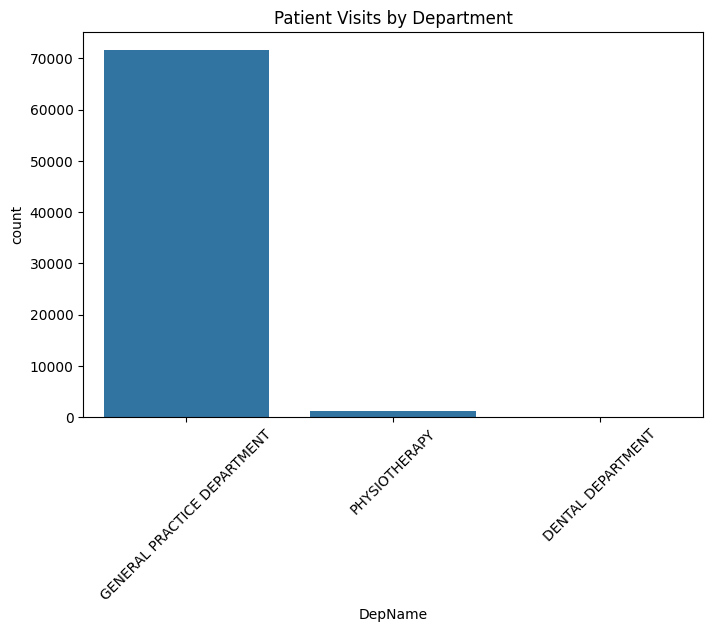

In [69]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='DepName'
)

plt.xticks(rotation=45)
plt.title('Patient Visits by Department')
plt.show()

Shows which department handles most patient visits.

## Insurance Distribution

In [71]:
df['Insurance'].value_counts().head(10)

Insurance
NATIONAL HEALTH INSURANCE COMPANY (DAMAN)    33809
OMAN INSURANCE COMPANY                       12278
ALMADALLAH                                    6882
FMC NETWORK UAE MANAGEMENT CONSULTANCY        6410
NAS ADMINISTRATION SERVICES LIMITED           5776
AAFIYA                                        3902
MEDNET GLOBAL HEALTHCARE SOLUTIONS LLC        2259
E CARE MEDICAL SERVICES                        530
INAYAH TPA LLC - ABU DHABI                     522
ARAB GULF HEALTH SERVICES (NEXTCARE)           256
Name: count, dtype: int64

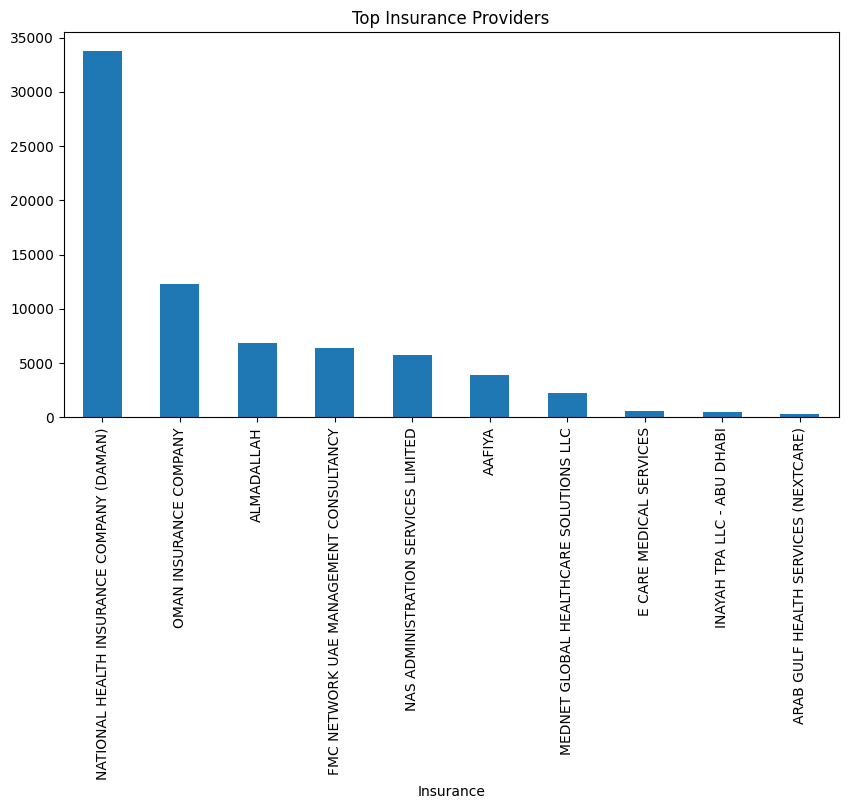

In [72]:
plt.figure(figsize=(10,5))

df['Insurance'].value_counts().head(10).plot(kind='bar')

plt.title('Top Insurance Providers')
plt.show()

## Bivariate Analysis

### Department vs Submission Amount

In [75]:
dept_submission = (
    df.groupby('DepName')['Submission Amount']
    .sum()
    .sort_values(ascending=False)
)

dept_submission

DepName
GENERAL PRACTICE DEPARTMENT    1736931.41
PHYSIOTHERAPY                    83887.00
DENTAL DEPARTMENT                 1712.00
Name: Submission Amount, dtype: float64

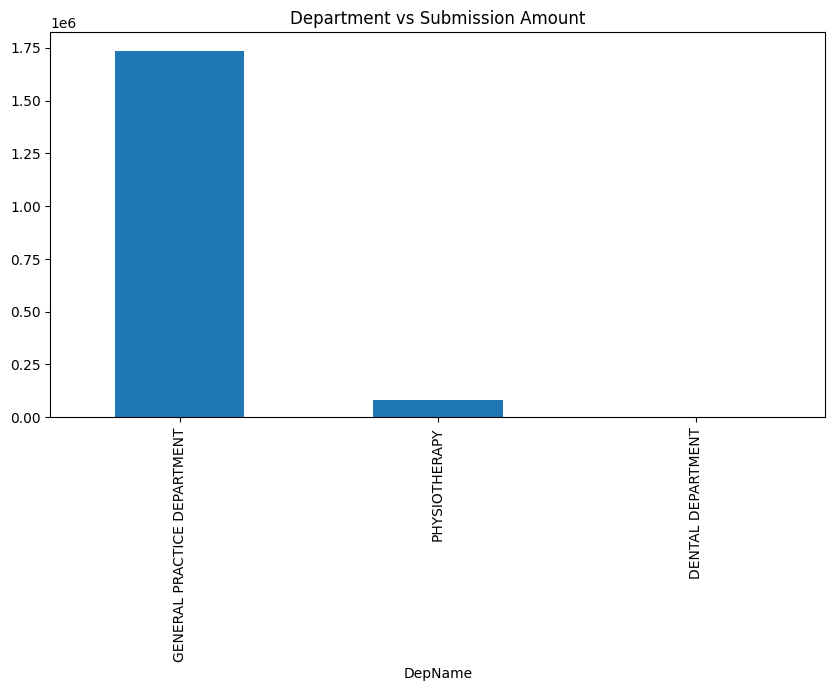

In [76]:
dept_submission.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Department vs Submission Amount')
plt.show()

Identifies highest revenue-generating departments.

### Insurance vs Rejected Amount

In [78]:
insurance_rejection = (
    df.groupby('Insurance')['Rejected Amount']
    .sum()
    .sort_values(ascending=False)
)

insurance_rejection.head(10)

Insurance
OMAN INSURANCE COMPANY                               181348.980
NAS ADMINISTRATION SERVICES LIMITED                   25463.481
NATIONAL HEALTH INSURANCE COMPANY (DAMAN)             13845.510
ALMADALLAH                                             5550.880
ARAB GULF HEALTH SERVICES (NEXTCARE)                   3024.270
FMC NETWORK UAE MANAGEMENT CONSULTANCY                 1703.190
AAFIYA                                                  488.000
E CARE MEDICAL SERVICES                                 269.800
NATIONAL HEALTH INSURANCE COMPANY (DAMAN) - THIQA        56.000
NEURON LLC - ABU DHABI                                   22.990
Name: Rejected Amount, dtype: float64

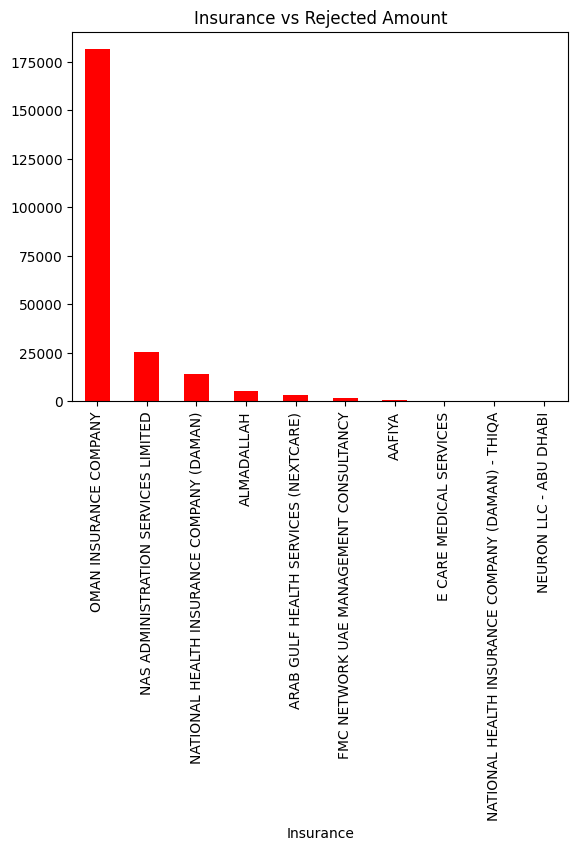

In [79]:
insurance_rejection.head(10).plot(
    kind='bar',
    color='red'
)

plt.title('Insurance vs Rejected Amount')
plt.show()

Shows insurers contributing most rejections.

### Doctor vs Accepted Amount

In [81]:
doctor_acceptance = (
    df.groupby('DocName')['Accepted Amount']
    .sum()
    .sort_values(ascending=False)
)

doctor_acceptance.head(10)

DocName
RAGHA MOHAN KOTHUR               3252.085
GAJENDRA VASHISTH                2685.800
SHER BAZ  KHAN                   2581.470
SHAKIR ULLAH KHAN                2514.760
SHARIFUL ISLAM                   2399.750
NURUL ISLAM                      1793.050
SENTHILNATHAN    SELVAKUMAR      1518.000
Habib  Khan                       480.290
MOHAMED RASEEN MOHAMED IDREES     299.000
ASHFAQ UR REHMAN                    8.800
Name: Accepted Amount, dtype: float64

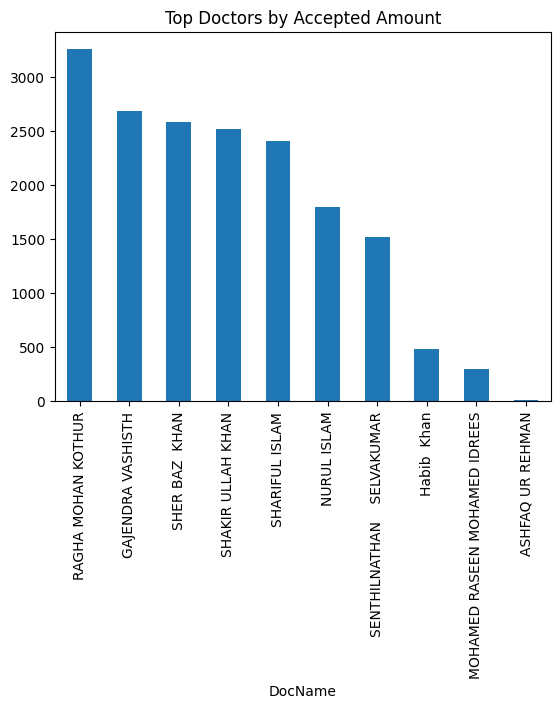

In [82]:
doctor_acceptance.head(10).plot(
    kind='bar'
)

plt.title('Top Doctors by Accepted Amount')
plt.show()

### Submission Amount vs Accepted Amount

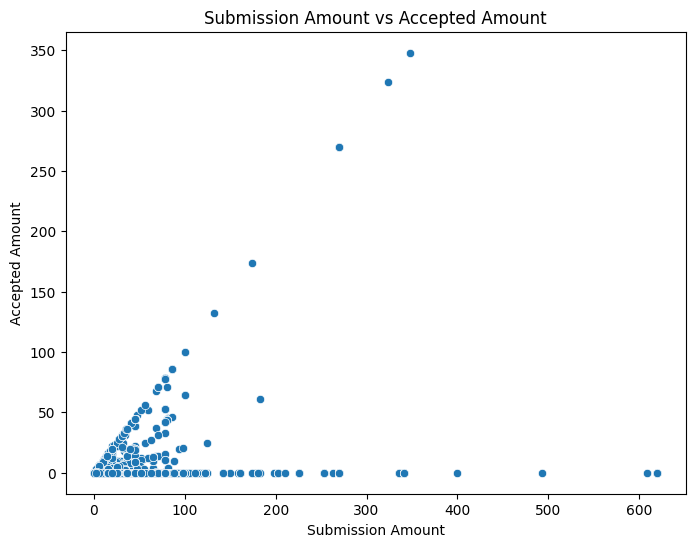

In [125]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Submission Amount',
    y='Accepted Amount'
)

plt.title('Submission Amount vs Accepted Amount')
plt.xlabel('Submission Amount')
plt.ylabel('Accepted Amount')

plt.show()

### Multivariate Analysis

In [84]:
pivot1 = pd.pivot_table(
    df,
    values='Submission Amount',
    index='DepName',
    columns='Insurance',
    aggfunc='sum',
    fill_value=0
)

pivot1

Insurance,AAFIYA,ABU DHABI NATIONAL INSURANCE COMPANY,ALMADALLAH,ARAB GULF HEALTH SERVICES (NEXTCARE),E CARE MEDICAL SERVICES,FMC NETWORK UAE MANAGEMENT CONSULTANCY,INAYAH TPA LLC - ABU DHABI,MEDNET GLOBAL HEALTHCARE SOLUTIONS LLC,METLIFE INSURANCE,NAS ADMINISTRATION SERVICES LIMITED,NATIONAL GENERAL INSURANCE COMPANY,NATIONAL HEALTH INSURANCE COMPANY (DAMAN),NATIONAL HEALTH INSURANCE COMPANY (DAMAN) - THIQA,NEURON LLC - ABU DHABI,OMAN INSURANCE COMPANY
DepName,,,,,,,,,,,,,,,
DENTAL DEPARTMENT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,1312.000,0.0,0.000,0.0,0.00,400.00
GENERAL PRACTICE DEPARTMENT,103260.92,1516.56,154420.64,7517.83,14057.26,102299.48,13218.45,58842.05,396.0,159534.425,83.3,781703.885,1566.8,208.19,338305.62
PHYSIOTHERAPY,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.000,0.0,83887.000,0.0,0.00,0.00


## Heatmap

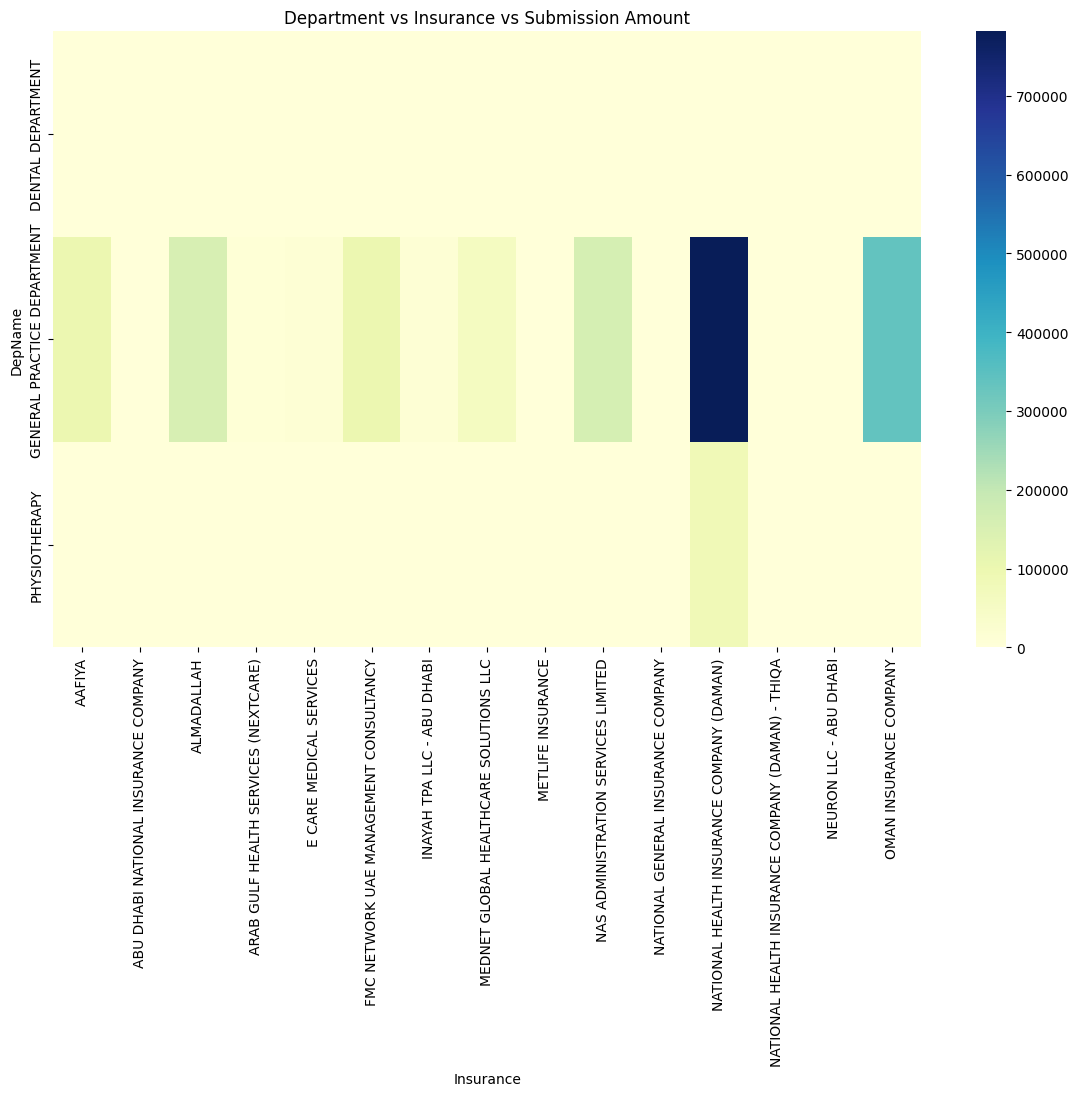

In [86]:
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot1,
    cmap='YlGnBu'
)

plt.title('Department vs Insurance vs Submission Amount')
plt.show()

Shows which insurance companies contribute most revenue in each department.

# GroupBy Analysis

## Department-wise Financial Summary

In [89]:
dept_summary = (
    df.groupby('DepName')
    .agg({
        'Submission Amount':'sum',
        'Accepted Amount':'sum',
        'Rejected Amount':'sum',
        'Outstanding':'sum'
    })
)

dept_summary

,Submission Amount,Accepted Amount,Rejected Amount,Outstanding
DepName,,,,
DENTAL DEPARTMENT,1712.00,0.000,0.000,0.000
GENERAL PRACTICE DEPARTMENT,1736931.41,15716.005,231799.101,318857.417
PHYSIOTHERAPY,83887.00,1817.000,0.000,8940.000


# Insurance-wise Financial Summary

In [93]:
insurance_summary = (
    df.groupby('Insurance')
    .agg({
        'Submission Amount':'sum',
        'Accepted Amount':'sum',
        'Rejected Amount':'sum'
    })
)

insurance_summary.sort_values(
    by='Submission Amount',
    ascending=False
)

,Submission Amount,Accepted Amount,Rejected Amount
Insurance,,,
NATIONAL HEALTH INSURANCE COMPANY (DAMAN),865590.885,5516.175,13845.510
OMAN INSURANCE COMPANY,338705.620,3736.750,181348.980
NAS ADMINISTRATION SERVICES LIMITED,160846.425,2168.640,25463.481
ALMADALLAH,154420.640,657.120,5550.880
AAFIYA,103260.920,269.000,488.000
FMC NETWORK UAE MANAGEMENT CONSULTANCY,102299.480,4510.100,1703.190
MEDNET GLOBAL HEALTHCARE SOLUTIONS LLC,58842.050,452.020,20.000
E CARE MEDICAL SERVICES,14057.260,46.800,269.800
INAYAH TPA LLC - ABU DHABI,13218.450,80.000,0.000


# Item Group-wise Analysis

In [95]:
item_summary = (
    df.groupby('Item Group')
    .agg({
        'Submission Amount':'sum',
        'Accepted Amount':'sum',
        'Rejected Amount':'sum'
    })
)

item_summary

,Submission Amount,Accepted Amount,Rejected Amount
Item Group,,,
Consultation,1338881.820,10082.490,185175.460
Lab,42665.100,868.400,1163.160
Medicines,46529.539,1768.015,3325.140
Procedure,394453.951,4814.100,42135.341


# Correlation Analysis

## Correlation Matrix

In [100]:
corr = df[
    [
        'Submission Amount',
        'Accepted Amount',
        'Rejected Amount',
        'Received Amount',
        'Outstanding'
    ]
].corr()

corr

,Submission Amount,Accepted Amount,Rejected Amount,Received Amount,Outstanding
Submission Amount,1.000000,0.099501,0.309864,0.735946,0.321889
Accepted Amount,0.099501,1.000000,-0.014759,-0.016522,-0.018711
Rejected Amount,0.309864,-0.014759,1.000000,-0.141522,-0.068248
Received Amount,0.735946,-0.016522,-0.141522,1.000000,-0.192440
Outstanding,0.321889,-0.018711,-0.068248,-0.192440,1.000000


## Heatmap

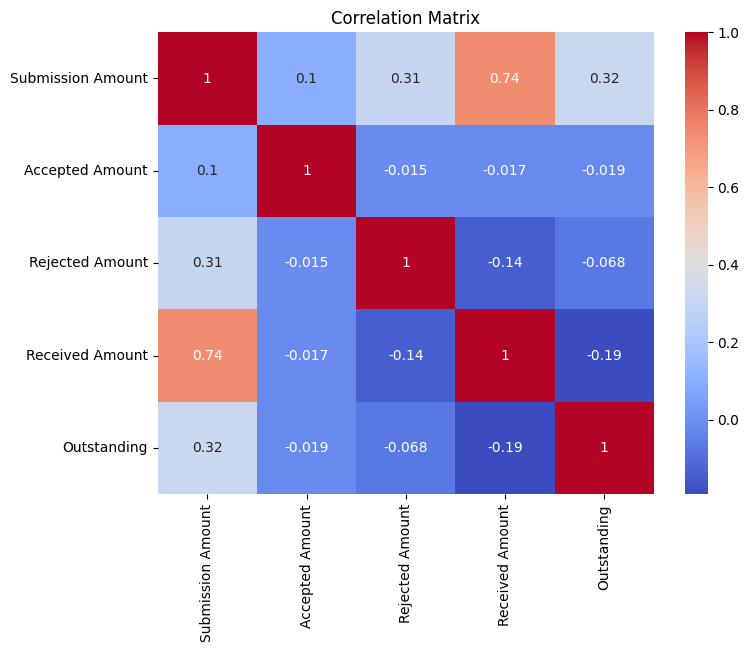

In [102]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

- Positive correlation close to 1 indicates strong positive relationship.
- Negative correlation close to -1 indicates inverse relationship.
- Accepted Amount usually has a strong positive correlation with Submission Amount.
- Rejected Amount often shows a negative relationship with Accepted Amount.

# Final Conclusion

## Key Findings

- General Practice Department generates the highest revenue (AED 1.74M).
- Dr. Ragha Mohan Kothur contributes the highest claim value among doctors.
- Daman Insurance is the largest insurance provider by claim amount.
- Oman Insurance records the highest rejected claims, indicating possible claim approval challenges.
- Consultation services account for the majority of healthcare revenue.
- Claim revenue is heavily concentrated within General Practice and Consultation activities.
- Certain doctors consistently generate higher accepted claim values.
- Submission Amount and Accepted Amount have a strong positive correlation.
- Rejected Amount significantly impacts overall collections and revenue realization.

# Business Insights

1. Department Performance Analysis

- Certain departments contribute significantly more claim revenue than others.
- High-performing departments generate a larger share of submission and accepted amounts.
- Low-performing departments may require operational review or increased patient engagement.

2. Doctor Performance Analysis

- A small number of doctors are likely responsible for a large proportion of claim submissions.
- Identifying top-performing doctors can help management understand best practices and patient demand patterns.

3. Insurance Company Analysis

- Some insurance providers contribute a higher volume of claims and revenue.
- Strong relationships with high-volume insurers can improve cash flow and operational efficiency.

4. Claim Rejection Analysis

- Rejection amounts vary across insurance providers.
- High rejection rates may indicate documentation issues, coding errors, policy limitations, or insurer-specific requirements.
- Reducing rejections can directly improve revenue realization.

5. Item Group Contribution
   
- A few service categories may account for the majority of healthcare revenue.
- Understanding which services generate the most claims helps optimize resource allocation and inventory planning.

7. Monthly Trend Analysis
   
- Submission amounts may show seasonal fluctuations throughout the year.
- Peak periods can help management plan staffing, resources, and budgeting more effectively.
  
9. Distribution Analysis
    
- Most claims are likely concentrated in lower-value ranges, while a smaller number of high-value claims contribute significantly to total revenue.
- Outliers indicate exceptional cases that may require additional review.
  
10. Relationship Between Submission and Acceptance
  
- A strong positive relationship between submission and accepted amounts suggests effective claim processing.
- Large gaps between submitted and accepted amounts indicate opportunities for improving claim quality and documentation.

# Learning Outcomes

Through this project, the following skills were developed:

### 1. Data Cleaning and Preparation
- Handling missing values and inconsistent records.
- Converting date columns into proper datetime format.
- Preparing healthcare claims data for analysis.
### 2. Exploratory Data Analysis (EDA)
- Understanding data distributions and trends.
- Identifying patterns, anomalies, and outliers.
- Generating meaningful business insights from raw data.
### 3. Data Visualization
- Creating bar charts, pie charts, line graphs, histograms, scatter plots, box plots, and heatmaps.
- Selecting appropriate visualizations for different analytical objectives.
- Statistical Understanding
### 4. Interpreting correlations among numerical variables.
- Analyzing distributions and identifying skewness.
- Understanding relationships between claim-related financial metrics.
### 5. Business Analytics
- Translating analytical findings into actionable business recommendations.
- Evaluating operational performance using data-driven methods.
### 6. Python and Data Analysis Tools
- Using Pandas for data manipulation.
- Using Matplotlib and Seaborn for visualization.
- Applying analytical techniques in a real-world healthcare dataset.

# Future Scope

### 1. Predictive Claim Approval Model
Develop machine learning models to predict claim approval or rejection before submission.
### 2. Rejection Risk Analysis
Identify factors contributing to claim rejections and proactively reduce rejection rates.
### 3. Revenue Forecasting
Use time-series forecasting models to estimate future submission and acceptance amounts.
### 4. Insurance Performance Dashboard
Build an interactive dashboard using:
- Power BI
- Tableau
- Streamlit
- Dash
### 5.  Doctor and Department Performance Monitoring
Create automated KPI tracking systems for management.
### 6. Fraud Detection
Implement anomaly detection techniques to identify suspicious or unusual claim patterns.
### 7. Patient Analytics
Analyze patient demographics and treatment trends for strategic healthcare planning.
### 8. Real-Time Reporting
Integrate hospital management systems with analytics platforms for real-time insights and decision-making.

# Recommendations

- Investigate the high rejection rate from Oman Insurance.
- Increase focus on Consultation services as they drive most revenue.
- Analyze approval patterns for high-performing doctors.
- Expand successful General Practice services to further improve revenue.

# Overall Project Summary

This project focused on analyzing healthcare insurance claim data to understand operational performance, revenue generation, claim acceptance behavior, and insurance provider effectiveness. Using Python-based data analysis techniques, the dataset was cleaned, processed, and explored through various visualizations including bar charts, pie charts, line graphs, histograms, scatter plots, box plots, and heatmaps.

The analysis revealed key trends in departmental performance, doctor contributions, insurance company behavior, claim rejection patterns, and monthly submission trends. Relationships between submission amounts, accepted amounts, rejected amounts, and outstanding balances were also examined to assess claim processing efficiency.

The project demonstrates how data analytics can support healthcare organizations in improving claim management, reducing revenue leakage, enhancing operational efficiency, and making data-driven decisions. The findings provide valuable insights that can help hospitals optimize processes, strengthen insurer relationships, and improve overall financial performance.

# Conclusion

The healthcare claims analytics project successfully transformed raw operational data into actionable business intelligence. Through exploratory data analysis and visualization, important patterns and opportunities for improvement were identified. The project highlights the value of data-driven decision-making in healthcare administration and establishes a foundation for future predictive analytics and business intelligence initiatives.